In [1]:
import os, sys
while not os.path.isdir("data") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")
for _p in (os.getcwd(), os.path.join(os.getcwd(), "PROD", "pipeline")):
    if _p not in sys.path: sys.path.insert(0, _p)

# Importance des variables : faut-il en retirer du pool enrichi ?

On mesure l'importance de **deux familles** de variables :
1. Les **~35 variables statiques** du feature engineering (montant, structure, garantie…).
2. Les **10 variables de propension-fraude produit** (`product_feats.py`) : pour chaque
   granularité (SKU, modèle, catégorie, marque), le **taux de fraude** appris sur le
   train, **agrégé sur le panier** (max / moyenne) + le taux du modèle dominant + un
   comptage d'articles à haut risque. Elles captent le produit **exact** (un *iPad Pro
   Cellular* fraude à 11 %, une *Apple Watch* à 0 %), là où `dom_make = APPLE` mélangeait tout.

**La règle** : une variable est retenue si son importance **SHAP** dépasse celle d'une
sentinelle aléatoire **de même cardinalité** (binaire, comptage ou continue).

**Pourquoi trois sentinelles et pas une.** Les arbres favorisent mécaniquement les
variables à **beaucoup de valeurs distinctes** : une variable continue peut être
découpée à des dizaines d'endroits et accumule de l'importance, là où un drapeau 0/1
ne peut être coupé qu'une fois. Un repère aléatoire *continu* unique serait donc un
juge injuste, qui éliminerait les drapeaux quelle que soit leur pertinence. On compare
donc chaque variable à un repère de **sa propre nature**.

**Sans fuite** : les taux produit sont appris sur le *train* du split et appliqués au
*holdout* par simple lookup ; les catégorielles `dom_cat` / `dom_make` passent par un
CatBoostEncoder *fit* sur le train uniquement.

> **Ce que ce notebook conclut** : la mesure d'importance est instructive, mais
> le retrait qu'elle suggère se révèle **contre-productif** sur ce jeu. On garde les
> 45 variables. Le détail de cette vérification est en fin de notebook.


## Chargement et construction du pool

On charge les variables statiques, on ajoute les 3 sentinelles, puis on isole un
holdout. Les features produit sont calculées **après** le split : tables apprises
sur le train, appliquées au train et au holdout.


In [2]:
import json, numpy as np, pandas as pd
import lightgbm as lgb, shap
from category_encoders import CatBoostEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from product_feats import load_baskets, fit_tables, apply_tables, PRODUCT_COLS
import plotly.graph_objects as go
import os
from IPython.display import Image
import warnings; warnings.filterwarnings("ignore")
SEED = 42

F   = pd.read_csv("data/features_train.csv")
y   = F["fraud"].astype(int)
ids = F["ID"]
Xs  = F.drop(columns=["ID", "fraud"]).rename(columns={"rand": "rand_num"})   # statiques + sentinelle continue
CAT = ["dom_cat", "dom_make"]

def col_type(s, name):
    if name in CAT: return "continue"
    u = pd.unique(s.dropna())
    if set(u) <= {0, 1}: return "binaire"
    uf = np.asarray(u, float)
    if np.all(uf == np.floor(uf)) and len(u) <= 30: return "comptage"
    return "continue"

# sentinelles : rand_num (existe déjà), rand_bin, rand_cnt (calibrée sur les comptages statiques)
counts = [c for c in Xs.columns if c not in CAT and col_type(Xs[c], c) == "comptage"]
K = int(round(np.median([Xs[c].nunique() for c in counts])))
rng = np.random.RandomState(0)
Xs["rand_bin"] = rng.randint(0, 2, len(Xs))
Xs["rand_cnt"] = rng.randint(0, K, len(Xs))

B = load_baskets("data/X_train_clean.csv")
print(f"{len(F):,} paniers | {Xs.shape[1]} statiques (+sentinelles) | {len(PRODUCT_COLS)} produit | baskets {len(B):,}")

C:\Users\ayman\anaconda3\envs\fraude\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


92,780 paniers | 38 statiques (+sentinelles) | 10 produit | baskets 92,780


In [3]:
# split + features produit sans fuite
idx = np.arange(len(F))
itr, iho = train_test_split(idx, test_size=0.20, stratify=y, random_state=SEED)
id_tr, id_ho = ids.iloc[itr].tolist(), ids.iloc[iho].tolist()
ytr = y.iloc[itr].reset_index(drop=True); yho = y.iloc[iho].reset_index(drop=True)

tables, g = fit_tables(id_tr, ytr.to_numpy(), B)                 # tables apprises sur le train
pf_tr = apply_tables(tables, g, id_tr, B).reset_index(drop=True)  # lookup train
pf_ho = apply_tables(tables, g, id_ho, B).reset_index(drop=True)  # lookup holdout (sans son label)

Xtr = pd.concat([Xs.iloc[itr].reset_index(drop=True), pf_tr], axis=1)
Xho = pd.concat([Xs.iloc[iho].reset_index(drop=True), pf_ho], axis=1)

types = {c: col_type(Xtr[c], c) for c in Xtr.columns}
types["rand_bin"] = "binaire"; types["rand_cnt"] = "comptage"

enc = CatBoostEncoder(cols=CAT, random_state=SEED)
Xtr_e = enc.fit_transform(Xtr, ytr); Xho_e = enc.transform(Xho)

spw = (ytr == 0).sum() / (ytr == 1).sum()
model = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
    min_child_samples=50, subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    scale_pos_weight=spw, random_state=SEED, n_jobs=-1, verbosity=-1)
model.fit(Xtr_e, ytr)
ap = average_precision_score(yho, model.predict_proba(Xho_e)[:, 1])

expl = shap.TreeExplainer(model)(Xho_e)
if expl.values.ndim == 3: expl = expl[:, :, 1]
imp = pd.Series(np.abs(expl.values).mean(0), index=Xho_e.columns)
print(f"pool : {Xtr_e.shape[1]} variables | PR-AUC holdout : {ap:.4f}")

pool : 48 variables | PR-AUC holdout : 0.1397


## Le graphe SHAP (beeswarm)

Position = poussée vers la fraude (droite) / le légitime (gauche) ; couleur = valeur
de la variable. On s'attend à voir les **features produit** (SKU / modèle) dominer.


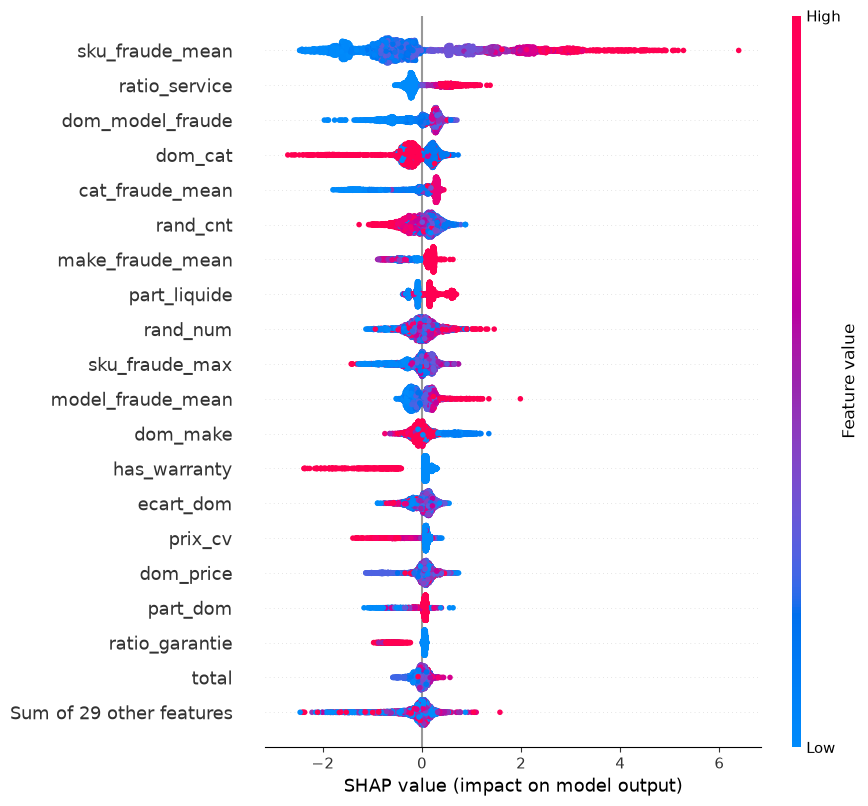

In [4]:
idx4 = np.random.RandomState(0).choice(len(Xho_e), size=min(4000, len(Xho_e)), replace=False)
shap.plots.beeswarm(expl[idx4], max_display=20)

## Décision : garder ce qui bat sa sentinelle

Chaque variable est comparée à la sentinelle **de son type** (binaire / comptage /
continue). On garde celles dont l'importance SHAP la dépasse.


In [5]:
SENT = {"binaire": "rand_bin", "comptage": "rand_cnt", "continue": "rand_num"}
for t, snt in SENT.items():
    print(f"seuil {t:9s} ({snt}) : {imp[snt]:.4f}")

real = [c for c in Xtr.columns if c not in SENT.values()]
tab = pd.DataFrame({
    "type":  [types[f] for f in real],
    "imp":   [round(imp[f], 4) for f in real],
    "seuil": [round(imp[SENT[types[f]]], 4) for f in real],
    "produit": [f in PRODUCT_COLS for f in real],
}, index=real)
tab["gardée"] = tab["imp"] > tab["seuil"]
tab.sort_values("imp", ascending=False)

seuil binaire   (rand_bin) : 0.0517
seuil comptage  (rand_cnt) : 0.2403
seuil continue  (rand_num) : 0.2142


,type,imp,seuil,produit,gardée
sku_fraude_mean,continue,1.2243,0.2142,True,True
ratio_service,continue,0.3204,0.2142,False,True
dom_model_fraude,continue,0.3191,0.2142,True,True
dom_cat,continue,0.3097,0.2142,False,True
cat_fraude_mean,continue,0.3017,0.2142,True,True
make_fraude_mean,continue,0.2335,0.2142,True,True
part_liquide,continue,0.2187,0.2142,False,True
sku_fraude_max,continue,0.2123,0.2142,True,False
model_fraude_mean,continue,0.1916,0.2142,True,False
has_warranty,binaire,0.1890,0.0517,False,True


In [6]:
kept    = tab.index[tab["gardée"]].tolist()
dropped = [c for c in real if c not in kept]
kept_prod = [c for c in kept if c in PRODUCT_COLS]
print(f"gardées ({len(kept)}) dont {len(kept_prod)} produit :\n  " + ", ".join(kept))
print(f"\nécartées ({len(dropped)}) :\n  " + ", ".join(dropped))

gardées (8) dont 4 produit :
  dom_cat, part_liquide, has_warranty, ratio_service, sku_fraude_mean, cat_fraude_mean, make_fraude_mean, dom_model_fraude

écartées (37) :
  total, dom_price, val_high, nb_biens_chers, prix_rond, dom_make, is_apple, is_pram_premium, is_cat_liquide, part_dom, part_top2, ecart_dom, prix_std, prix_cv, taille, is_mono, is_duo, is_3plus, nb_distinct, qty_total, max_qty, n_multi, nb_petits, nb_garanties, ratio_garantie, has_accessoires, has_delivery, nb_services, nb_cat_distinctes, nb_make_distinctes, nb_sans_marque, sku_fraude_max, model_fraude_max, model_fraude_mean, cat_fraude_max, make_fraude_max, nb_articles_risque


## La décision en image

Importance SHAP de chaque variable, **verte** si elle bat sa sentinelle, **grise**
sinon. Les traits pointillés marquent les trois seuils, un par cardinalité : on voit
qu'ils sont très différents, ce qui justifie de ne pas juger toutes les variables au
même étalon.

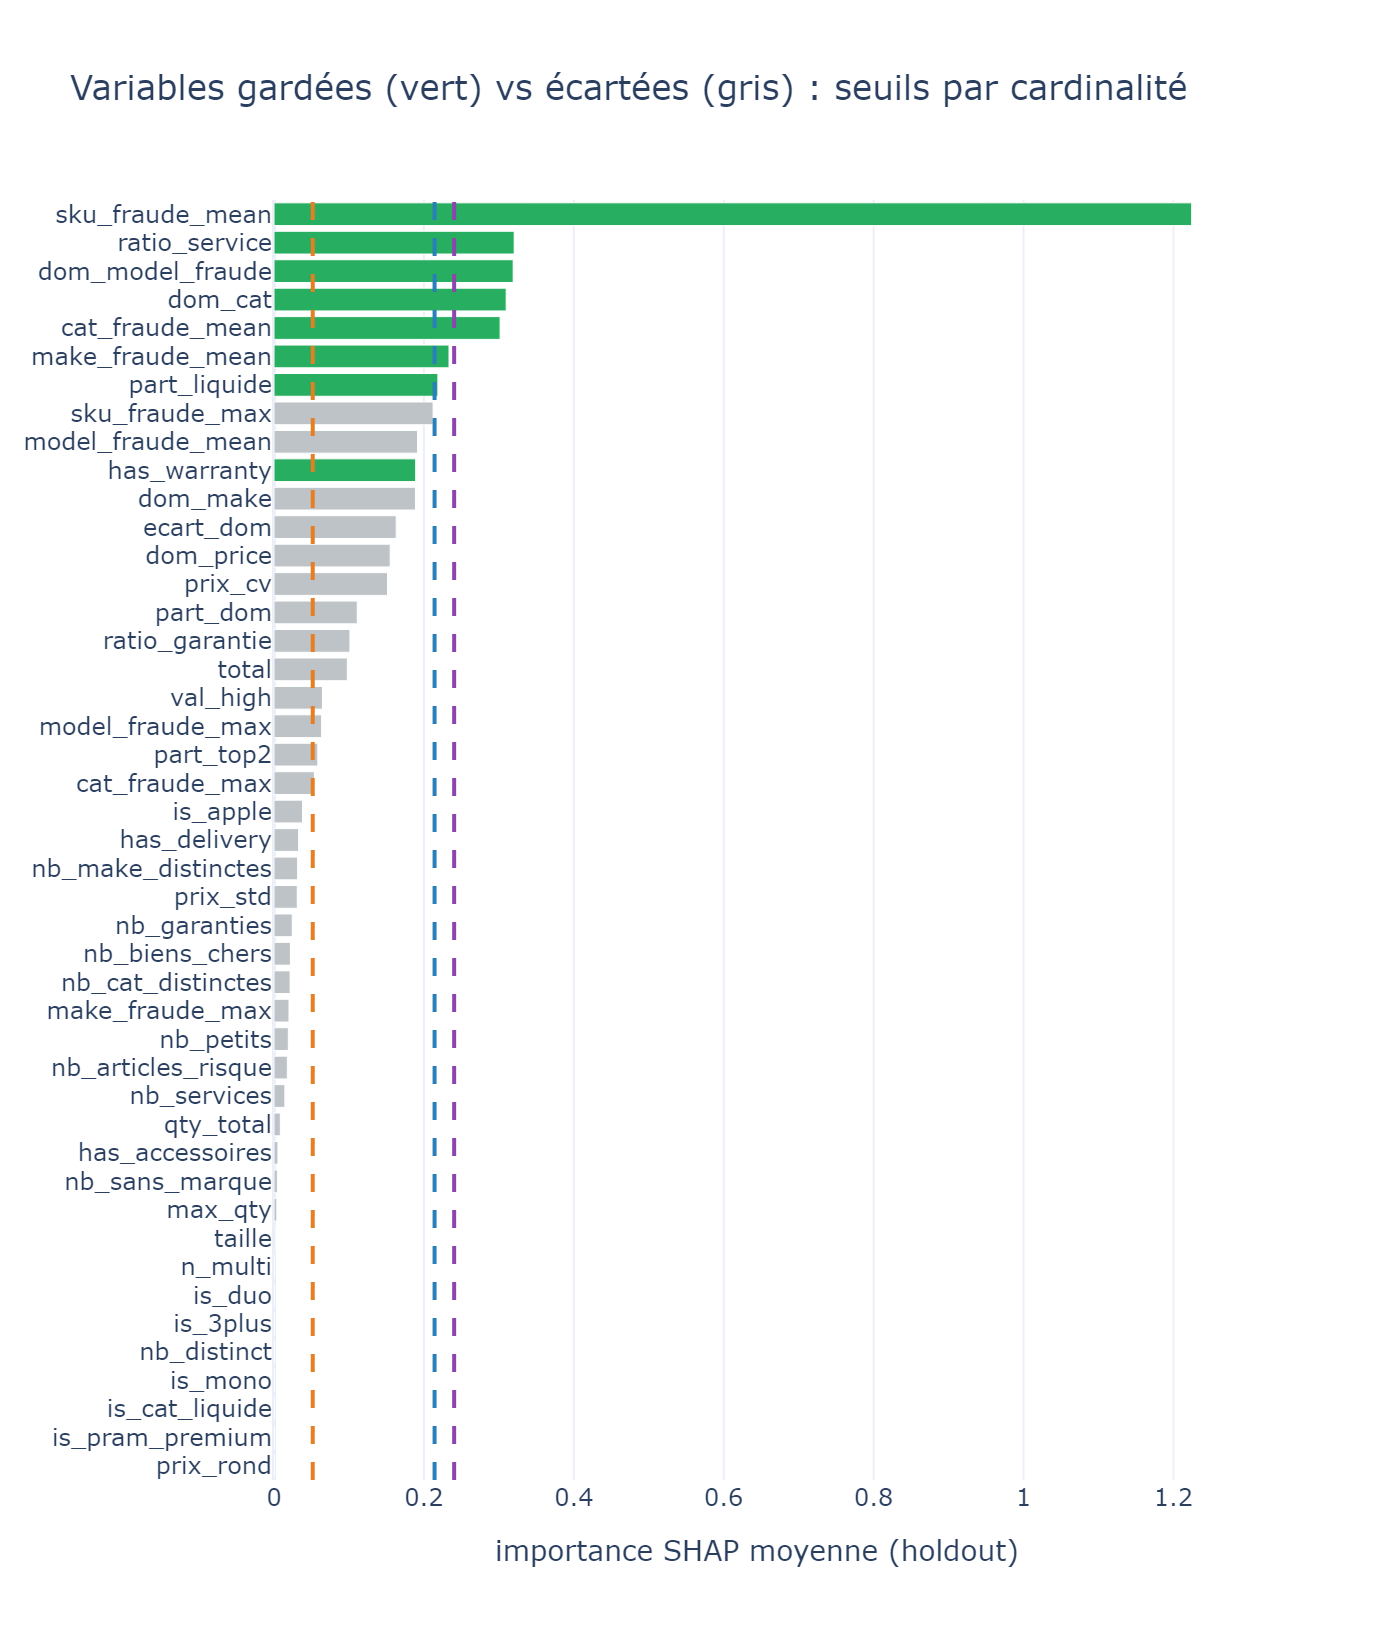

In [7]:
s = imp.drop(index=list(SENT.values())).sort_values()
colors = ["#27ae60" if tab.loc[f, "gardée"] else "#bdc3c7" for f in s.index]
fig = go.Figure(go.Bar(x=s.values, y=s.index, orientation="h", marker_color=colors))
for snt, c in {"rand_num": "#2980b9", "rand_cnt": "#8e44ad", "rand_bin": "#e67e22"}.items():
    fig.add_vline(x=imp[snt], line_dash="dash", line_color=c)
fig.update_layout(template="plotly_white", height=820,
    title="Variables gardées (vert) vs écartées (gris) : seuils par cardinalité",
    xaxis_title="importance SHAP moyenne (holdout)")
os.makedirs("DEV/images", exist_ok=True)
fig.write_image("DEV/images/fs_variables_gardees.png", scale=2)
display(Image(filename="DEV/images/fs_variables_gardees.png"))

## Faut-il retirer des variables ? Vérification empirique

Le SHAP a classé les variables, mais **en retirer n'est pas toujours gagnant** : quand
des variables sont complémentaires, retirer les « moins importantes » peut coûter.
On tranche par la donnée : PR-AUC en validation croisée, **liste sélectionnée** contre
**pool complet** (features produit recalculées dans chaque pli, sans fuite).


In [8]:
from sklearn.model_selection import StratifiedKFold
statf = [c for c in Xs.columns if c not in ("rand_num", "rand_bin", "rand_cnt")]  # statiques
full  = statf + PRODUCT_COLS
def cv(feats):
    skf = StratifiedKFold(5, shuffle=True, random_state=SEED); sc = []
    for jtr, jva in skf.split(F, y):
        idt, idv = ids.iloc[jtr].tolist(), ids.iloc[jva].tolist()
        yt = y.iloc[jtr].reset_index(drop=True); yv = y.iloc[jva].reset_index(drop=True)
        tb, gg = fit_tables(idt, yt.to_numpy(), B)
        pt = apply_tables(tb, gg, idt, B).reset_index(drop=True)
        pv = apply_tables(tb, gg, idv, B).reset_index(drop=True)
        St = Xs[statf].iloc[jtr].reset_index(drop=True); Sv = Xs[statf].iloc[jva].reset_index(drop=True)
        Xt = pd.concat([St, pt], axis=1)[feats]; Xv = pd.concat([Sv, pv], axis=1)[feats]
        cc = [c for c in CAT if c in feats]
        if cc:
            e = CatBoostEncoder(cols=cc, random_state=SEED); Xt = e.fit_transform(Xt, yt); Xv = e.transform(Xv)
        mm = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
            min_child_samples=50, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
            random_state=SEED, n_jobs=-1, verbosity=-1); mm.fit(Xt, yt)
        sc.append(average_precision_score(yv, mm.predict_proba(Xv)[:, 1]))
    return float(np.mean(sc))
ap_kept, ap_full = cv(kept), cv(full)
print(f"PR-AUC CV, sélection ({len(kept)} feats)   : {ap_kept:.4f}")
print(f"PR-AUC CV, pool complet ({len(full)} feats) : {ap_full:.4f}")
print("=> on garde le POOL COMPLET" if ap_full > ap_kept + 0.003 else "=> la sélection suffit")

PR-AUC CV, sélection (8 feats)   : 0.1148
PR-AUC CV, pool complet (45 feats) : 0.1445
=> on garde le POOL COMPLET


**Conclusion** : sur ce jeu, retirer des variables est **contre-productif** : les variables
sont largement **complémentaires**, et le SHAP marginal sur un seul tirage
sous-estime les variables corrélées (il coupe `total`, `dom_price`, `sku_fraude_max`…
qui aident en réalité). On **conserve le pool complet enrichi** pour le modèle. Le
SHAP garde toute sa valeur comme **analyse** : il montre que les features produit
dominent et rendent `dom_make` redondant.


In [9]:
FINAL = full        # pool complet enrichi = statiques + produit
sel = {
    "features":     FINAL,
    "static_cols":  statf,
    "product_cols": PRODUCT_COLS,
    "cat_cols":     [c for c in CAT if c in FINAL],
    "note":         f"pool complet conservé (CV {ap_full:.3f}) > sélection SHAP (CV {ap_kept:.3f})",
}
with open("data/features_kept.json", "w", encoding="utf-8") as f:
    json.dump(sel, f, ensure_ascii=False, indent=2)
print("écrit : data/features_kept.json")
print(f"{len(FINAL)} variables pour le modèle (dont {len(PRODUCT_COLS)} produit)")

écrit : data/features_kept.json
45 variables pour le modèle (dont 10 produit)


## Récapitulatif

- **Pool enrichi** : variables statiques (EDA) + propension-fraude **produit**
  (SKU / modèle / catégorie / marque, agrégées au panier).
- **Analyse SHAP** : les features **produit dominent** et rendent `dom_make` redondant
  . Le produit *exact* porte le signal, pas la marque grossière.
- **Décision, vérifiée par la donnée** : retirer des variables est **contre-productif** ici
  (PR-AUC en validation croisée : **0,115** avec les 8 variables sélectionnées contre
  **0,144** avec le pool complet, soit **+26 %**) → on **garde tout le pool enrichi**.
- **Sans fuite** partout : taux produit appris sur le train (lookup côté holdout) ;
  `dom_cat`/`dom_make` via CatBoostEncoder *fit* train.
- **Sortie** : `data/features_kept.json` = le pool complet + la liste des colonnes
  produit (à recalculer in-fold dans le modèle).
